# Notebook 02 — NLP Subscription Detection (FR3)
**Team 7 — Mansi & Samyak | AI Subscription & Auto-Debit Intelligence System**

Trains TF-IDF + Logistic Regression and Naive Bayes on transaction descriptions.
Compares both models, picks the best one, and saves `subscription_model.pkl`.

In [3]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
os.makedirs('models', exist_ok=True)
print('✅ Imports ready')


✅ Imports ready


## 1. Load Data

In [4]:
DATA_PATH = r'C:\Users\mansi.apet\Downloads\AI_SUBSCRIPTION_SYSTEM_FINAL\data\transactions_cleaned.csv'

df = pd.read_csv(DATA_PATH)
df = df.rename(columns={'SubscriptionFlag': 'is_subscription'})

print(f'Shape       : {df.shape}')
print(f'\nTarget distribution:')
print(df['is_subscription'].value_counts())
df.head()


Shape       : (137700, 13)

Target distribution:
is_subscription
1    75187
0    62513
Name: count, dtype: int64


,CustomerID,CustomerName,TransactionID,Date,Description,Amount,Balance,Merchant,TransactionType,is_subscription,Status,Frequency,Description_Clean
0,CUST100000,Karan Verma,TXN28728463,2023-01-02,MONTHLY SALARY CREDIT,143839.29,223750.99,Employer,CREDIT,0,SUCCESS,monthly,MONTHLY SALARY CREDIT
1,CUST100000,Karan Verma,TXN31429110,2023-01-14,NETFLIX.COM MONTHLY SUB,661.05,223750.99,Netflix,DEBIT,1,SUCCESS,monthly,NETFLIX.COM MONTHLY SUBSCRIPTION
2,CUST100000,Karan Verma,TXN23756669,2023-02-02,MONTHLY SALARY CREDIT,143839.29,367590.28,Employer,CREDIT,0,SUCCESS,monthly,MONTHLY SALARY CREDIT
3,CUST100000,Karan Verma,TXN55176955,2023-02-14,NETFLIX.COM MONTHLY SUB,654.12,2667703.75,Netflix,DEBIT,1,SUCCESS,monthly,NETFLIX.COM MONTHLY SUBSCRIPTION
4,CUST100000,Karan Verma,TXN83197857,2023-03-02,MONTHLY SALARY CREDIT,143839.29,511429.57,Employer,CREDIT,0,SUCCESS,monthly,MONTHLY SALARY CREDIT


## 2. Add Ambiguous Examples (edge-case augmentation)

In [5]:
# Subscription edge cases (BRD FR3)
aug_sub = pd.DataFrame({'Description': [
    'NETFLX.COM MONTHLY SUB', 'SPOTIFY PREMIUM', 'AMZN PRIME',
    'ADOBE CREATIVE CLOUD', 'MICROSOFT 365 PLAN'
], 'is_subscription': 1})

# False-positive examples (salary, EMI, ATM must NOT be classified as subscriptions)
aug_non = pd.DataFrame({'Description': [
    'AUTO PAY 4521', 'ACH DEBIT 0293',
    'MONTHLY SALARY', 'SALARY CREDIT',
    'EMI DEBIT HOME LOAN', 'ATM WITHDRAWAL'
], 'is_subscription': 0})

df = pd.concat(
    [df[['Description','is_subscription']], aug_sub, aug_non],
    ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Dataset after augmentation: {df.shape}')
print(df['is_subscription'].value_counts())


Dataset after augmentation: (137711, 2)
is_subscription
1    75192
0    62519
Name: count, dtype: int64


## 3. Text Preprocessing

In [6]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_description'] = df['Description'].apply(preprocess_text)

# Quick check on key examples
test_cases = ['NETFLX.COM MONTHLY SUB', 'SPOTIFY PREMIUM', 'AUTO PAY 4521', 'MONTHLY SALARY']
print('Preprocessing check:')
for t in test_cases:
    print(f'  {t!r:35} → {preprocess_text(t)!r}')

df[['Description','clean_description']].head()


Preprocessing check:
  'NETFLX.COM MONTHLY SUB'            → 'netflx com monthly sub'
  'SPOTIFY PREMIUM'                   → 'spotify premium'
  'AUTO PAY 4521'                     → 'auto pay'
  'MONTHLY SALARY'                    → 'monthly salary'


,Description,clean_description
0,LOAN EMI SBI,loan emi sbi
1,ELECTRICITY BILL AUTO PAY,electricity bill auto pay
2,MONTHLY SALARY CREDIT,monthly salary credit
3,YOUTUBE PREMIUM MONTHLY,youtube premium monthly
4,YOUTUBE PREMIUM MONTHLY,youtube premium monthly


## 4. Keyword Baseline (for comparison)

In [7]:
def keyword_predict(text):
    t = str(text).lower()
    if any(fp in t for fp in ['salary','loan','emi','atm']): return 0
    if any(kw in t for kw in ['netflix','spotify','prime','subscription']): return 1
    return 0

df['keyword_pred'] = df['Description'].apply(keyword_predict)
print(f'Keyword Baseline Accuracy: {accuracy_score(df["is_subscription"], df["keyword_pred"]):.4f}')


Keyword Baseline Accuracy: 0.5144


## 5. Train-Test Split + TF-IDF

In [8]:
X = df['clean_description']
y = df['is_subscription']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Train : {len(X_train):,}   Test : {len(X_test):,}')
print(f'TF-IDF features : {X_train_tfidf.shape[1]:,}')


Train : 110,168   Test : 27,543
TF-IDF features : 151


## 6. Train Both Models

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes':         MultinomialNB(),
}

trained = {}
for name, m in models.items():
    m.fit(X_train_tfidf, y_train)
    trained[name] = m
    print(f'{name} trained ✅')


Logistic Regression trained ✅
Naive Bayes trained ✅


## 7. Compare Models

In [10]:
def eval_model(name, model):
    y_pred = model.predict(X_test_tfidf)
    return {'Model': name,
            'Accuracy':  round(accuracy_score(y_test, y_pred),  6),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 6),
            'Recall':    round(recall_score(y_test, y_pred,    zero_division=0), 6),
            'F1':        round(f1_score(y_test, y_pred,        zero_division=0), 6)}, y_pred

results, preds = [], {}
for name, m in trained.items():
    metrics, y_pred = eval_model(name, m)
    results.append(metrics)
    preds[name] = y_pred

results_df = pd.DataFrame(results)
print('Model Comparison:')
print(results_df.to_string(index=False))


Model Comparison:
              Model  Accuracy  Precision  Recall       F1
Logistic Regression  0.997967   0.996290     1.0 0.998142
        Naive Bayes  0.995425   0.991691     1.0 0.995828


## 8. Classification Report + Confusion Matrix (Best Model)

Best Model: Logistic Regression

                  precision    recall  f1-score   support

Non-Subscription       1.00      1.00      1.00     12504
    Subscription       1.00      1.00      1.00     15039

        accuracy                           1.00     27543
       macro avg       1.00      1.00      1.00     27543
    weighted avg       1.00      1.00      1.00     27543



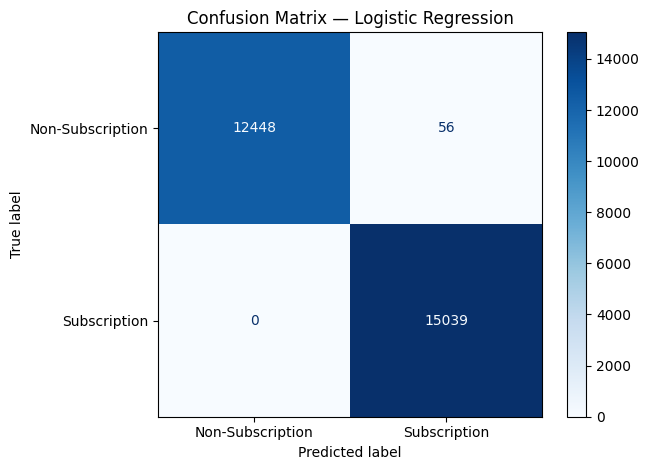

In [11]:
best_name  = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = trained[best_name]
y_pred_best = best_model.predict(X_test_tfidf)

print(f'Best Model: {best_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['Non-Subscription','Subscription']))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Non-Subscription','Subscription']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()


## 9. Misclassification Analysis

In [12]:
test_df = pd.DataFrame({
    'Description': df.loc[X_test.index, 'Description'].values,
    'Actual':    y_test.values,
    'Predicted': y_pred_best
})

fp = test_df[(test_df['Actual']==0) & (test_df['Predicted']==1)]
fn = test_df[(test_df['Actual']==1) & (test_df['Predicted']==0)]

print(f'False Positives : {len(fp)}')
print(fp['Description'].head(5).tolist())
print(f'\nFalse Negatives : {len(fn)}')
print(fn['Description'].head(5).tolist())


False Positives : 56
['UNKNOWN TRANSACTION', 'UNKNOWN TRANSACTION', 'UNKNOWN TRANSACTION', 'UNKNOWN TRANSACTION', 'UNKNOWN TRANSACTION']

False Negatives : 0
[]
